# RNN (Recurent Neural Network) - LSTM (Long Short Term Memory) - GRU (Gated Recurent Unit)
## RNN

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Dense, SimpleRNN
from tensorflow.keras.models import Sequential
# ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Generate example data
X = np.random.rand(100, 10, 1)
y = np.random.randint(0, 2, size=(100,))

In [3]:
X.shape, y.shape

((100, 10, 1), (100,))

In [4]:
# Define the model
model = Sequential([
    SimpleRNN(32, input_shape=(10, 1)),
    Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X, y, epochs=10, batch_size=32)

# Evaluate the model
loss, accuracy = model.evaluate(X, y)
print('Test Loss:', loss)
print('Test Accuracy:', accuracy)

Epoch 1/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.4790 - loss: 0.7372
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5377 - loss: 0.6816
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5903 - loss: 0.6688
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5351 - loss: 0.7029
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5716 - loss: 0.6772
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6329 - loss: 0.6421
Epoch 7/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6390 - loss: 0.6422
Epoch 8/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5909 - loss: 0.6574
Epoch 9/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6030 - loss: 0.6502
Epoch 10/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6643 - loss: 0.6426
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5890 - loss: 0.6680 
Test Loss: 0.6528148055076599
Test Accuracy: 0.6000000238418579


## LSTM (Long Short Term Memory) is a special kind of RNN, capable of learning long-term dependencies.

In [5]:
import seaborn as sns
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.layers import Dense, LSTM
from tensorflow.keras.models import Sequential

# Load flight data
flights = sns.load_dataset('flights')

# Convert data to time series
df = pd.DataFrame({'value': flights['passengers'].values}, index=pd.date_range(start='1949-01-01', end='1960-12-01', freq='MS'))
df.head()

,value
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [6]:
df.head()

,value
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.8928
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.6567
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.5582
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.4580
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.3498
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.2450
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1830
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1599
Epoch 9/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1457
Epoch 10/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1673
Epoch 11/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1853
Epoch 12/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1821
Epoch 13/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.1665 
Epoch 14/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1539
Epoch 15/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1525
Epoch 16/100
4/4 ━

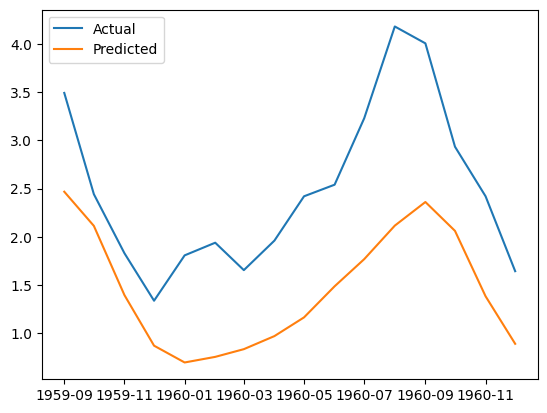

In [7]:
# Split data into training and testing sets
train_size = int(len(df) * 0.8)
train_data, test_data = df.iloc[:train_size], df.iloc[train_size:]

# Normalize the data
train_mean = train_data.mean()
train_std = train_data.std()
train_data = (train_data - train_mean) / train_std
test_data = (test_data - train_mean) / train_std

# Convert data to sequences
def to_sequences(data, seq_length):
    X = []
    y = []
    for i in range(len(data)-seq_length-1):
        X_seq = data[i:(i+seq_length)].values
        X.append(X_seq)
        y_seq = data.iloc[i+seq_length].values[0]
        y.append(y_seq)
    return np.array(X), np.array(y)

seq_length = 12
X_train, y_train = to_sequences(train_data, seq_length)
X_test, y_test = to_sequences(test_data, seq_length)

# Reshape input to be [samples, time steps, features]
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# Define the model
model = Sequential([
    LSTM(32, input_shape=(seq_length, 1)),
    Dense(1)
])

# Compile the model
model.compile(optimizer='adam', loss='mse')

# Train the model
history = model.fit(X_train, y_train, epochs=100, batch_size=32)

# Evaluate the model
loss = model.evaluate(X_test, y_test)
print('Test Loss:', loss)

# Make predictions on test data
y_pred = model.predict(X_test)

# Plot the predictions and actual values
import matplotlib.pyplot as plt
plt.plot(test_data.index[seq_length+1:], y_test, label='Actual')
plt.plot(test_data.index[seq_length+1:], y_pred, label='Predicted')
plt.legend()
plt.show()

# Explanation of the LSTM Model Code
1. **Data Preparation**: 
   - The data is normalized and converted into sequences for training and testing.
   - The sequences are reshaped to fit the input requirements of the LSTM layer.

2. **Model Definition**:
   - A Sequential model is created with an LSTM layer (32 units) followed by a Dense layer with 1 unit for regression.

3. **Compilation**:
   - The model is compiled using the Adam optimizer and Mean Squared Error (MSE) loss function.

4. **Training**:
   - The model is trained on the training data for 100 epochs with a batch size of 32.

5. **Evaluation**:
   - The model's performance is evaluated on the test data, and the test loss is printed.

6. **Prediction and Visualization**:
   - Predictions are made on the test data.
   - A plot is generated to compare the actual and predicted values over time.

## let's build a simple RNN-based character-level text generator using a sample text. We'll use a sequence-to-sequence prediction approach to predict the next character in a sequence.

In [8]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Sample text data
text = "hello world! this is a simple text example for rnn."
chars = sorted(list(set(text))) # Get unique characters
char_to_int = dict((c, i) for i, c in enumerate(chars))
int_to_char = dict((i, c) for i, c in enumerate(chars))

# Create input-output sequences
seq_length = 10
X = []
y = []

for i in range(len(text) - seq_length):
    seq_in = text[i:i + seq_length]
    seq_out = text[i + seq_length]
    X.append([char_to_int[char] for char in seq_in])
    y.append(char_to_int[seq_out])

X = np.reshape(X, (len(X), seq_length, 1)) / float(len(chars)) # Normalize
y = tf.keras.utils.to_categorical(y)

# Define model
model = Sequential([
    LSTM(128, input_shape=(X.shape[1], X.shape[2])),
    Dense(len(chars), activation='softmax')
])

# Compile and train
model.compile(loss='categorical_crossentropy', optimizer='adam')
model.fit(X, y, epochs=100, batch_size=10, verbose=1)

# Predict a sequence
start = np.random.randint(0, len(X)-1)
pattern = X[start]
print("Seed:")
print("\"", ''.join([int_to_char[int(value*len(chars))] for value in pattern]), "\"")

for i in range(50): # Generate 50 characters
    x = np.reshape(pattern, (1, len(pattern), 1))
    prediction = model.predict(x, verbose=1)
    index = np.argmax(prediction)
    result = int_to_char[index]
    seq_in = [int_to_char[int(value*len(chars))] for value in pattern]
    print(result, end="")
    pattern = np.append(pattern, index/float(len(chars)))
    pattern = pattern[1:len(pattern)]

print("\n")


Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 2.9440
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 2.9148
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 2.9088
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 2.8788
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 2.8525
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 2.7795
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 2.7761
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 2.7537
Epoch 9/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 2.7441
Epoch 10/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 2.7090
Epoch 11/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 2.6702
Epoch 12/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 2.7133
Epoch 13/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 2.7342
Epoch 14/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 2.6980
Epoch 15/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 2.7546
Epoch 16/100
5/5 ━━

# Explanation of the Character-Level Text Generator Code
1. **Data Preparation**:
   - The sample text is processed to extract unique characters.
   - A mapping between characters and integers is created.
   - Input-output sequences are generated, where the input is a sequence of characters, and the output is the next character in the sequence.
   - The input sequences are normalized, and the output is one-hot encoded.

2. **Model Definition**:
   - A Sequential model is created with an LSTM layer (128 units) followed by a Dense layer with a softmax activation function to predict the next character.

3. **Compilation and Training**:
   - The model is compiled using the categorical cross-entropy loss function and the Adam optimizer.
   - The model is trained on the prepared data for 100 epochs with a batch size of 10.

4. **Sequence Prediction**:
   - A random seed sequence is selected from the input data.
   - The model generates the next 50 characters by predicting the next character based on the current sequence and appending it to the sequence iteratively.

5. **Output**:
   - The generated text is printed, starting from the seed sequence and including the predicted characters.

- Here, we first convert our sample text into sequences of characters. Each sequence of characters (X) corresponds to a next character (y). The model is trained to predict y from X.

- After training, we take a random seed sequence and use the model to predict the next 50 characters. The output will show the initial seed and the generated text based on it.

## GRU (Gated Recurrent Unit) is a variation of LSTM. It has fewer parameters than LSTM, as it lacks an output gate.

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.4198
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.4198
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.2888
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.2888
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.2692
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.2692
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1829
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1829
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.1694
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.1694
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.1495
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.1495
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1574
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1574
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1674
Epoch 9/100
4/4 ━━━━━━━━━

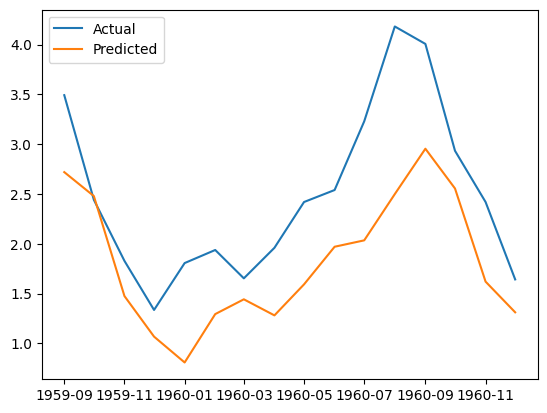

In [9]:
import seaborn as sns
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.layers import Dense, GRU  # Note the change here
from tensorflow.keras.models import Sequential

# Load flight data
flights = sns.load_dataset('flights')

# Convert data to time series
df = pd.DataFrame({'value': flights['passengers'].values}, index=pd.date_range(start='1949-01-01', end='1960-12-01', freq='MS'))

# Split data into training and testing sets
train_size = int(len(df) * 0.8)
train_data, test_data = df.iloc[:train_size], df.iloc[train_size:]

# Normalize the data
train_mean = train_data.mean()
train_std = train_data.std()
train_data = (train_data - train_mean) / train_std
test_data = (test_data - train_mean) / train_std

# Convert data to sequences
def to_sequences(data, seq_length):
    X = []
    y = []
    for i in range(len(data)-seq_length-1):
        X_seq = data[i:(i+seq_length)].values
        X.append(X_seq)
        y_seq = data.iloc[i+seq_length].values[0]
        y.append(y_seq)
    return np.array(X), np.array(y)

seq_length = 12
X_train, y_train = to_sequences(train_data, seq_length)
X_test, y_test = to_sequences(test_data, seq_length)

# Reshape input to be [samples, time steps, features]
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# Define the model using GRU
model = Sequential([
    GRU(32, input_shape=(seq_length, 1)),  # Note the change here
    Dense(1)
])

# Compile the model
model.compile(optimizer='adam', loss='mse')

# Train the model
history = model.fit(X_train, y_train, epochs=100, batch_size=32)

# Evaluate the model
loss = model.evaluate(X_test, y_test)
print('Test Loss:', loss)

# Make predictions on test data
y_pred = model.predict(X_test)

# Plot the predictions and actual values
import matplotlib.pyplot as plt
plt.plot(test_data.index[seq_length+1:], y_test, label='Actual')
plt.plot(test_data.index[seq_length+1:], y_pred, label='Predicted')
plt.legend()
plt.show()

# Explanation of the GRU Model Code
1. **Data Preparation**:
   - The flight passenger data is normalized and converted into sequences for training and testing.
   - The sequences are reshaped to fit the input requirements of the GRU layer.

2. **Model Definition**:
   - A Sequential model is created with a GRU layer (32 units) followed by a Dense layer with 1 unit for regression.

3. **Compilation**:
   - The model is compiled using the Adam optimizer and Mean Squared Error (MSE) loss function.

4. **Training**:
   - The model is trained on the training data for 100 epochs with a batch size of 32.

5. **Evaluation**:
   - The model's performance is evaluated on the test data, and the test loss is printed.

6. **Prediction and Visualization**:
   - Predictions are made on the test data.
   - A plot is generated to compare the actual and predicted values over time.

## GRU on Text

In [10]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense  # Import GRU instead of LSTM

# Sample text data
text = "hello world! this is a simple text example for rnn."
chars = sorted(list(set(text)))  # Get unique characters
char_to_int = dict((c, i) for i, c in enumerate(chars))
int_to_char = dict((i, c) for i, c in enumerate(chars))

# Create input-output sequences
seq_length = 10
X = []
y = []

for i in range(len(text) - seq_length):
    seq_in = text[i:i + seq_length]
    seq_out = text[i + seq_length]
    X.append([char_to_int[char] for char in seq_in])
    y.append(char_to_int[seq_out])

X = np.reshape(X, (len(X), seq_length, 1)) / float(len(chars))  # Normalize
y = tf.keras.utils.to_categorical(y)

# Define model using GRU
model = Sequential([
    GRU(128, input_shape=(X.shape[1], X.shape[2])),  # Change LSTM to GRU here
    Dense(len(chars), activation='softmax')
])

# Compile and train
model.compile(loss='categorical_crossentropy', optimizer='adam')
model.fit(X, y, epochs=100, batch_size=10, verbose=1)

# Predict a sequence
start = np.random.randint(0, len(X)-1)
pattern = X[start]
print("Seed:")
print("\"", ''.join([int_to_char[int(value*len(chars))] for value in pattern]), "\"")

for i in range(50):  # Generate 50 characters
    x = np.reshape(pattern, (1, len(pattern), 1))
    prediction = model.predict(x, verbose=0)
    index = np.argmax(prediction)
    result = int_to_char[index]
    seq_in = [int_to_char[int(value*len(chars))] for value in pattern]
    print(result, end="")
    pattern = np.append(pattern, index/float(len(chars)))
    pattern = pattern[1:len(pattern)]

print("\n")

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 2.9328
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 2.9328
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.9043
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.9043
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 2.8758
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 2.8758
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.8679
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.8679
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 2.8344
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 2.8344
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 2.7969
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 2.7969
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 2.7593
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 2.7593
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 2.7524
Epoch 9/100
5/5 ━━━━━━━━━

# Explanation of the GRU-Based Character-Level Text Generator Code
1. **Data Preparation**:
   - The sample text is processed to extract unique characters.
   - A mapping between characters and integers is created.
   - Input-output sequences are generated, where the input is a sequence of characters, and the output is the next character in the sequence.
   - The input sequences are normalized, and the output is one-hot encoded.

2. **Model Definition**:
   - A Sequential model is created with a GRU layer (128 units) followed by a Dense layer with a softmax activation function to predict the next character.

3. **Compilation and Training**:
   - The model is compiled using the categorical cross-entropy loss function and the Adam optimizer.
   - The model is trained on the prepared data for 100 epochs with a batch size of 10.

4. **Sequence Prediction**:
   - A random seed sequence is selected from the input data.
   - The model generates the next 50 characters by predicting the next character based on the current sequence and appending it to the sequence iteratively.

5. **Output**:
   - The generated text is printed, starting from the seed sequence and including the predicted characters.

# About the Author

<div style="background-color: #f8f9fa; border-left: 5px solid #28a745; padding: 20px; margin-bottom: 20px; border-radius: 5px;">
  <h2 style="color: #28a745; margin-top: 0; font-family: 'Poppins', sans-serif;">Muhammad Atif Latif</h2>
  <p style="font-size: 16px; color: #495057;">Data Scientist & Machine Learning Engineer</p>
  
  <p style="font-size: 15px; color: #6c757d; margin-top: 15px;">
    Passionate about building AI solutions that solve real-world problems. Specialized in machine learning, 
    deep learning, and data analytics with experience implementing production-ready models.
  </p>
</div>

## Connect With Me

<div style="display: flex; flex-wrap: wrap; gap: 10px; margin-top: 15px;">
  <a href="https://github.com/m-Atif-Latif" target="_blank">
    <img src="https://img.shields.io/badge/GitHub-Follow-212121?style=for-the-badge&logo=github" alt="GitHub">
  </a>
  <a href="https://www.kaggle.com/matiflatif" target="_blank">
    <img src="https://img.shields.io/badge/Kaggle-Profile-20BEFF?style=for-the-badge&logo=kaggle" alt="Kaggle">
  </a>
  <a href="https://www.linkedin.com/in/muhammad-atif-latif-13a171318" target="_blank">
    <img src="https://img.shields.io/badge/LinkedIn-Connect-0077B5?style=for-the-badge&logo=linkedin" alt="LinkedIn">
  </a>
  <a href="https://x.com/mianatif5867" target="_blank">
    <img src="https://img.shields.io/badge/Twitter-Follow-1DA1F2?style=for-the-badge&logo=twitter" alt="Twitter">
  </a>
  <a href="https://www.instagram.com/its_atif_ai/" target="_blank">
    <img src="https://img.shields.io/badge/Instagram-Follow-E4405F?style=for-the-badge&logo=instagram" alt="Instagram">
  </a>
  <a href="mailto:muhammadatiflatif67@gmail.com">
    <img src="https://img.shields.io/badge/Email-Contact-D14836?style=for-the-badge&logo=gmail" alt="Email">
  </a>
</div>

---